In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn fastapi uvicorn joblib pydantic

  Using cached numpy-2.4.5-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached fastapi-0.136.1-py3-none-any.whl.metadata (28 kB)
  Using cached uvicorn-0.47.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 405.9 kB/s eta 0:00:001m305.5 kB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 1.4 MB/s eta 0:00:00 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [14]:
import os
os.getcwd()

'/home/syeda-zainab/diabetes-mlops'

In [18]:
import pandas as pd

df = pd.read_csv("diabetes_unclean.csv")
df.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [19]:
# Drop useless columns
df.drop(["ID", "No_Pation"], axis=1, inplace=True)

# Fix Gender values
df["Gender"] = df["Gender"].replace({
    "f": "F", "female": "F",
    "m": "M", "male": "M"
})

# Check unique values
df["Gender"].unique()

<StringArray>
['F', 'M']
Length: 2, dtype: str

In [20]:
# Numeric fill
df.fillna(df.median(numeric_only=True), inplace=True)

# Categorical fill
df.fillna(df.mode().iloc[0], inplace=True)

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...
1004,M,55.0,4.6,62.0,6.8,5.3,2.0,1.0,3.5,0.9,30.1,Y
1005,M,55.0,4.8,88.0,8.0,5.7,4.0,0.9,3.3,1.8,30.0,Y
1006,M,62.0,6.3,82.0,6.7,5.3,2.0,1.0,3.5,0.9,30.1,Y
1007,F,57.0,4.1,70.0,9.3,5.3,3.3,1.0,1.4,1.3,29.0,Y


In [21]:
df = pd.get_dummies(df, columns=["Gender"], drop_first=True)
df.head()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS,Gender_M
0,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,False
1,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N,True
2,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,False
3,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N,False
4,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N,True


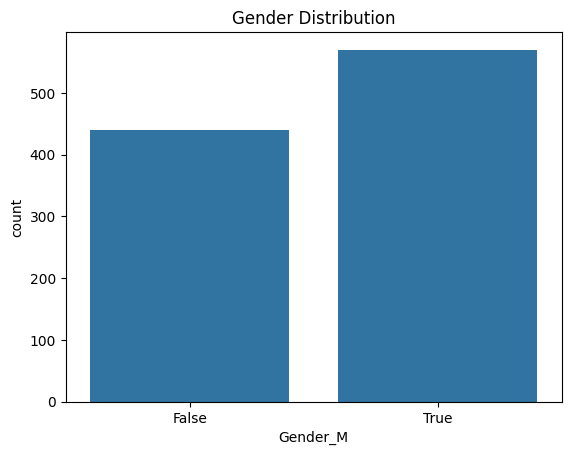

In [26]:
sns.countplot(x="Gender_M", data=df)
plt.title("Gender Distribution")
plt.show()

In [28]:
df.columns

Index(['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI',
       'CLASS', 'Gender_M'],
      dtype='str')

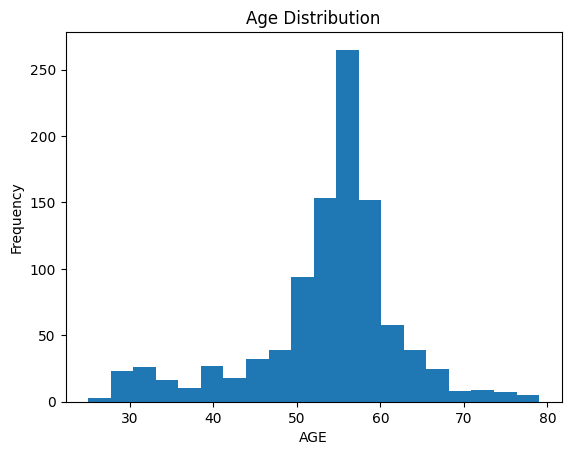

In [29]:
import matplotlib.pyplot as plt

plt.hist(df["AGE"], bins=20)
plt.title("Age Distribution")
plt.xlabel("AGE")
plt.ylabel("Frequency")
plt.show()

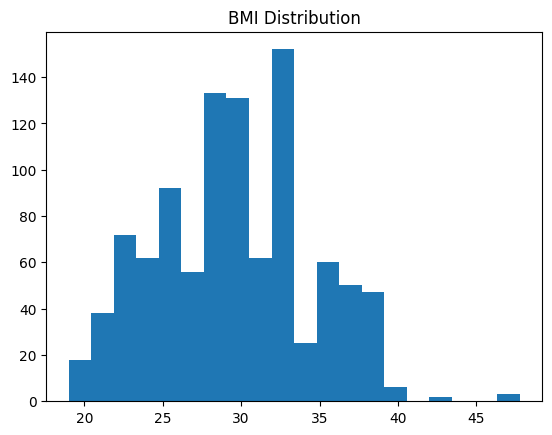

In [30]:
plt.hist(df["BMI"], bins=20)
plt.title("BMI Distribution")
plt.show()

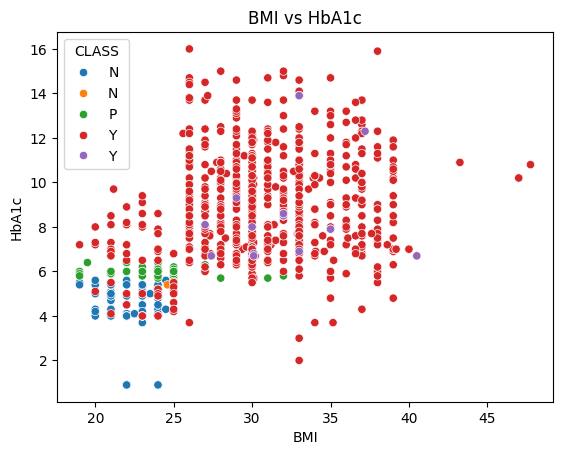

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="BMI", y="HbA1c", hue="CLASS", data=df)
plt.title("BMI vs HbA1c")
plt.show()

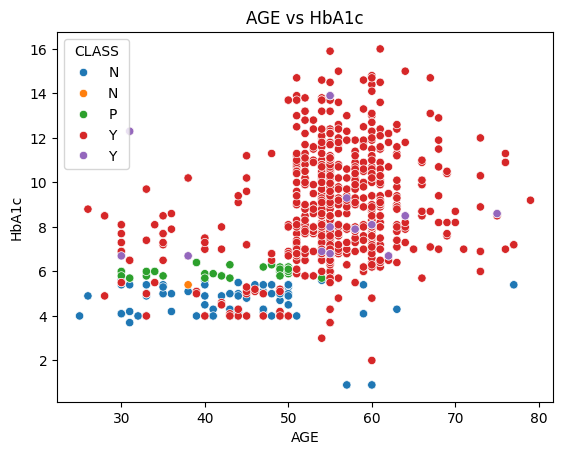

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="AGE", y="HbA1c", hue="CLASS", data=df)
plt.title("AGE vs HbA1c")
plt.show()

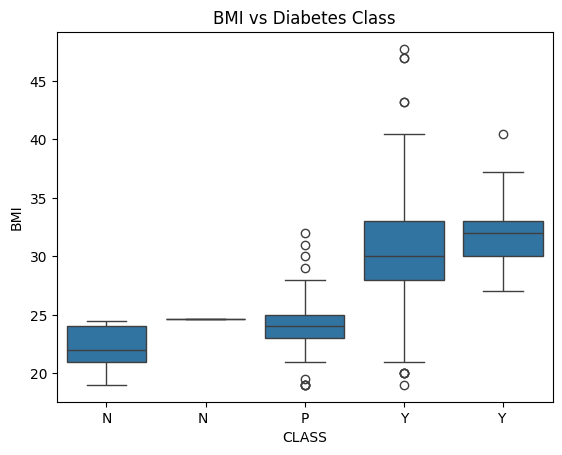

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="CLASS", y="BMI", data=df)
plt.title("BMI vs Diabetes Class")
plt.show()

In [38]:
from sklearn.model_selection import train_test_split

X = df.drop("CLASS", axis=1)
y = df["CLASS"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted"),
        "Recall": recall_score(y_test, pred, average="weighted"),
        "F1": f1_score(y_test, pred, average="weighted")
    }

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    results[name] = evaluate_model(model)

results

/home/syeda-zainab/diabetes-mlops/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/syeda-zainab/diabetes-mlops/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/syeda-zainab/diabetes-mlops/ve

{'Logistic Regression': {'Accuracy': 0.9240924092409241,
  'Precision': 0.9132845939487694,
  'Recall': 0.9240924092409241,
  'F1': 0.9168265061800298},
 'SVM': {'Accuracy': 0.834983498349835,
  'Precision': 0.6971974425165288,
  'Recall': 0.834983498349835,
  'F1': 0.7598950542536268},
 'Decision Tree': {'Accuracy': 0.966996699669967,
  'Precision': 0.95736098345799,
  'Recall': 0.966996699669967,
  'F1': 0.9621059040452513},
 'Random Forest': {'Accuracy': 0.976897689768977,
  'Precision': 0.9640801289431268,
  'Recall': 0.976897689768977,
  'F1': 0.9703232039137584},
 'KNN': {'Accuracy': 0.8877887788778878,
  'Precision': 0.8884200324794385,
  'Recall': 0.8877887788778878,
  'F1': 0.8875128303193213}}

In [42]:
import pandas as pd

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1
Logistic Regression,0.924092,0.913285,0.924092,0.916827
SVM,0.834983,0.697197,0.834983,0.759895
Decision Tree,0.966997,0.957361,0.966997,0.962106
Random Forest,0.976898,0.964080,0.976898,0.970323
KNN,0.887789,0.888420,0.887789,0.887513


In [43]:
best_model_name = results_df["F1"].idxmax()
best_model_name

'Random Forest'

In [45]:
import joblib

best_model = models[best_model_name]
best_model.fit(X_train, y_train)

joblib.dump(best_model, "diabetes_model.pkl")
joblib.dump(X.columns.tolist(), "training_columns.pkl")

['training_columns.pkl']